# Visualize trained deep-MPN weights across learning rules

Reload the deep-MPN (`dmpn`) networks saved by `train_mpn.py` (one seed, each
learning rule) and compare the three learned **weight matrices `W`** (not the
data-dependent modulation `M`):

| Component | Parameter | Shape | Role |
|---|---|---|---|
| **Input layer** | `W_initial_linear.weight` | `(n_embed, n_input)` | raw input → embedding |
| **Modulation-layer W** | `mp_layers[0].W` | `(n_hidden, n_embed)` | plastic MP weight (base of `W + W⊙M`) |
| **Output layer** | `W_output` | `(n_output, n_hidden)` | hidden → readout |

This is the RNN-comparable architecture (input → hidden → output), with the
plastic `M` playing the recurrence role. Set `SEED` / `RULES` below to match a
completed `train_mpn.py` run (checkpoints are assumed to be `dmpn`).

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

import _bootstrap  # noqa: F401  -- prepends ../core + ../scripts to sys.path
import mpn_tasks
import mpn
import train_mpn as tm      # ONLY for load_net (checkpoint-driven; ignores tm globals)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

# Rule display labels/colors kept LOCAL so this notebook does not depend on train_mpn globals.
RULE_LABEL = {"bptt": "BPTT", "local_diag_rflo": "diagonal RFLO",
              "local_exact_rowlocal": "exact row-local", "local_direct": "direct"}
RULE_COLOR = {"bptt": "#1f77b4", "local_diag_rflo": "#d62728",
              "local_exact_rowlocal": "#2ca02c", "local_direct": "#9467bd"}

## 1. Choose the run to load (by checkpoint name)

In [2]:
# --- run selection: point directly at saved checkpoints ---
# CKPT_STEM is the checkpoint filename up to (and INCLUDING) the trailing "_" that
# precedes "{rule}_seed{SEED}.pt". Copy it straight from a saved checkpoint name, e.g.
#   dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_eta1.00_lam0.99_
# Loaded per rule:  {CKPT_DIR}/{CKPT_STEM}{rule}_seed{SEED}.pt
# The net AND (below) the task config come from the checkpoints themselves — nothing
# is regenerated from train_mpn's globals.
CKPT_DIR  = tm.CKPT_DIR    # default <root>/checkpoints; set to any path you like
CKPT_STEM = "dmpn_contextdelaydm1_h200-200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_"
SEED      = 548787145             # the seed suffix on the checkpoint files
RULES     = ["bptt", "local_diag_rflo", "local_direct"]
DEVICE    = torch.device("cpu")

nets, ckpts = {}, {}
for rule in RULES:
    path = os.path.join(CKPT_DIR, f"{CKPT_STEM}{rule}_seed{SEED}.pt")
    ckpts[rule] = torch.load(path, map_location=DEVICE, weights_only=False)
    nets[rule]  = tm.load_net(path, device=DEVICE)   # rebuilds the net from ckpt net_params
    print(f"{rule:20} <- {os.path.basename(path)}")

any_net = nets[RULES[0]]
any_ck  = ckpts[RULES[0]]
RULESET = any_ck.get("ruleset") or any_ck.get("net_params", {}).get("ruleset", "?")
n_input  = any_net.n_input
n_hidden = any_net.n_hidden
n_output = any_net.n_output
print(f"\nruleset={RULESET}  n_input={n_input}  n_hidden={n_hidden}  n_output={n_output}")

# --- Output folder for saved figures (created if missing) ---
# Figures from this notebook land in <root>/figure/notebooks/, named from the
# checkpoint stem + seed + a per-figure suffix (self-describing, no cross-run
# collisions). save_fig(fig, suffix) writes <stem>seed<SEED>_<suffix>.png.
import _bootstrap
FIG_OUT_DIR = _bootstrap.ROOT / "figure" / "notebooks"
FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)   # create the intermediate folder

def save_fig(fig, suffix, dpi=150):
    """Save `fig` to FIG_OUT_DIR as <CKPT_STEM>seed<SEED>_<suffix>.png and return the path."""
    fname = f"{CKPT_STEM}seed{SEED}_{suffix}.png"
    out = FIG_OUT_DIR / fname
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    print(f"saved figure -> {out}")
    return out

print(f"figures will be saved to: {FIG_OUT_DIR}")

bptt                 <- dmpn_contextdelaydm1_h200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_bptt_seed342313018.pt
local_diag_rflo      <- dmpn_contextdelaydm1_h200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_local_diag_rflo_seed342313018.pt
local_direct         <- dmpn_contextdelaydm1_h200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_local_direct_seed342313018.pt

ruleset=contextdelaydm1  n_input=6  n_hidden=200  n_output=3
figures will be saved to: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure/notebooks


## 2. Extract the trained weight matrices

We visualize the learned **weights `W`** only (not the data-dependent modulation
`M`). For `dmpn` there are three: `W_initial_linear.weight` (input→embedding),
`mp_layers[0].W` (the plastic MP-layer weight), and `W_output` (readout).

In [3]:
# Weight matrices per rule, adaptive to ANY number of MP layers. comp[rule] holds
# W_in (input embedding), one W_mp{k} per MP layer k (0-based), and W_out (readout).
# `cols` is the ordered (key, title) list every downstream figure iterates over, so
# a deep MP stack shows each modulation layer's static weight SEPARATELY.
n_layers = len(any_net.mp_layers)

cols = [("W_in", "input layer  (embed×input)")]
for k in range(n_layers):
    cols.append((f"W_mp{k}", f"modulation layer {k}  W  (post×pre)"))
cols.append(("W_out", "output layer  W_out  (output×hidden)"))

comp = {}   # comp[rule] = {'W_in', 'W_mp0', 'W_mp1', ..., 'W_out'}
for rule, net in nets.items():
    d = {"W_in": net.W_initial_linear.weight.detach().cpu().numpy()}   # (n_embed, n_input)
    for k, mp in enumerate(net.mp_layers):
        d[f"W_mp{k}"] = mp.W.detach().cpu().numpy()                    # (post, pre)
    d["W_out"] = net.W_output.detach().cpu().numpy()                   # (n_output, n_hidden)
    comp[rule] = d
    mp_mags = "  ".join(f"|W_mp{k}| {np.abs(d[f'W_mp{k}']).mean():.3e}" for k in range(n_layers))
    print(f"{rule:20} |W_in| {np.abs(d['W_in']).mean():.3e}  {mp_mags}  "
          f"|W_out| {np.abs(d['W_out']).mean():.3e}")

bptt                 |W_in| 1.060e-01  |W_mp0| 6.908e-02  |W_out| 8.256e-02
local_diag_rflo      |W_in| 1.103e-01  |W_mp0| 7.379e-02  |W_out| 5.940e-02
local_direct         |W_in| 1.017e-01  |W_mp0| 7.515e-02  |W_out| 6.497e-02


## 3. Weight heatmaps — one row per learning rule

Columns: **input layer** `W_initial_linear`, **modulation-layer** `mp_layers[0].W`,
and **output layer** `W_output`. A shared symmetric color scale per column makes
rules directly comparable.

saved figure -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure/notebooks/dmpn_contextdelaydm1_h200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_seed342313018_weight_heatmaps.png


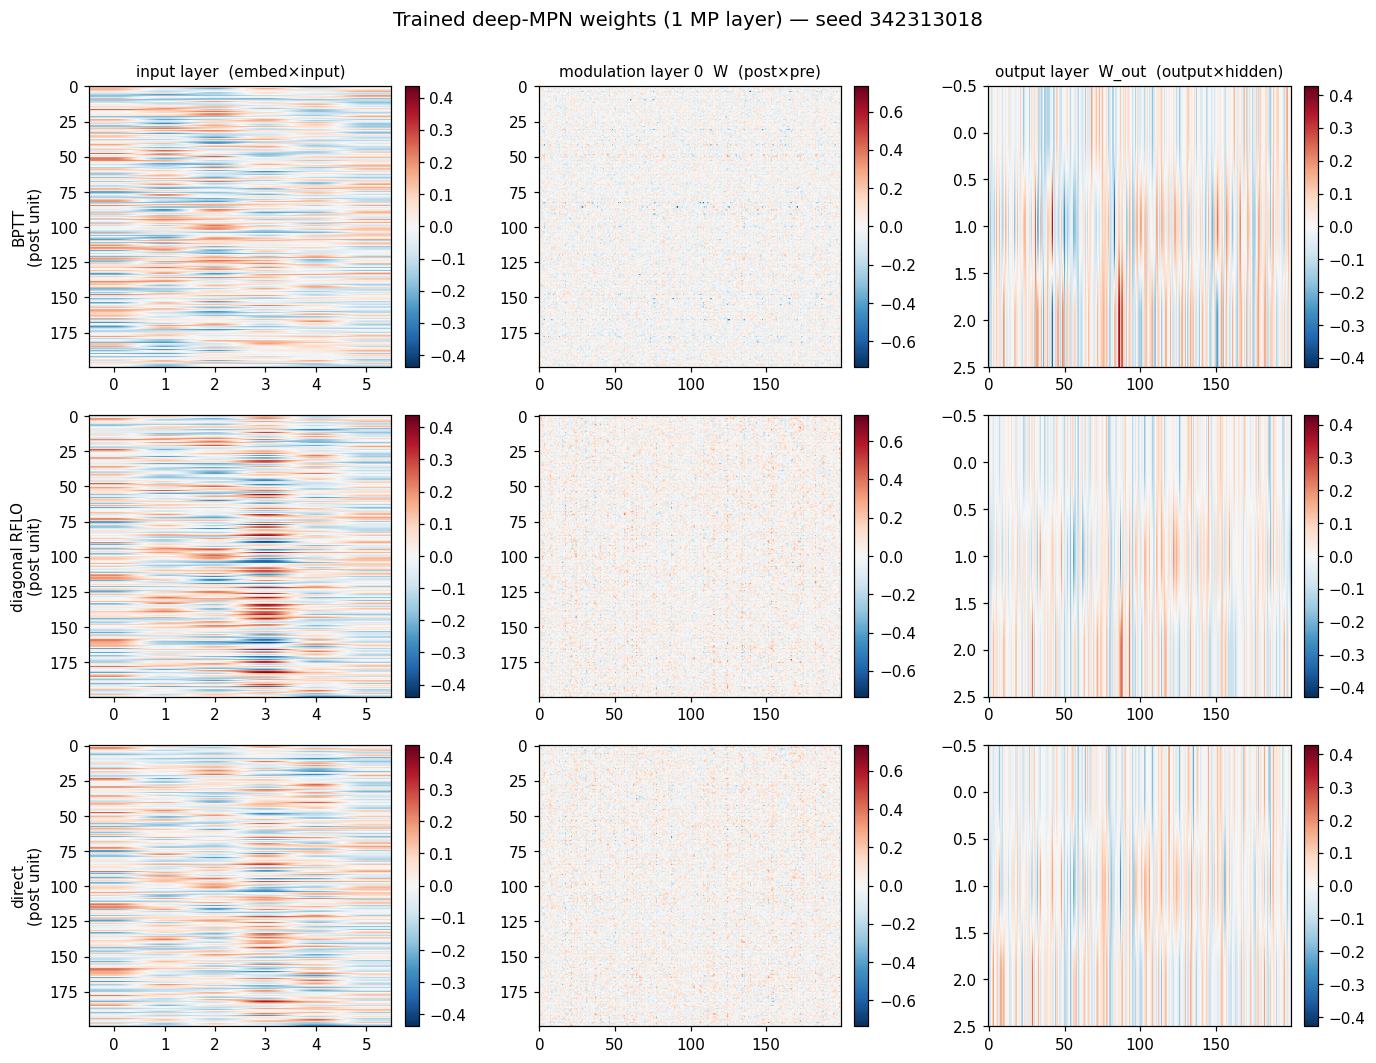

In [4]:
# Shared symmetric vlim per column (comparable across rules).
vlim = {key: max(np.abs(comp[r][key]).max() for r in RULES) for key, _ in cols}

nrows, ncols = len(RULES), len(cols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows),
                         squeeze=False)
for i, rule in enumerate(RULES):
    for j, (key, title) in enumerate(cols):
        ax = axes[i][j]
        v = vlim[key]
        im = ax.imshow(comp[rule][key], aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v)
        if i == 0:
            ax.set_title(title, fontsize=10)
        if j == 0:
            ax.set_ylabel(f"{RULE_LABEL.get(rule, rule)}\n(post unit)", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Trained deep-MPN weights ({n_layers} MP layer"
             f"{'s' if n_layers != 1 else ''}) — seed {SEED}", y=1.002, fontsize=13)
fig.tight_layout()
save_fig(fig, "weight_heatmaps")
plt.show()

### 3b. Trained-weight alignment to BPTT (cosine similarity & L1 distance)

All rules start from the SAME initialization (deepcopy) and see the SAME data, so
after training the differences in the LEARNED weights measure how far each local
rule's solution drifts from the exact-gradient (BPTT) solution, per weight matrix.
We report, for every non-BPTT rule and each component (input embedding, each MP
layer's W, readout):
  • cosine similarity  cos(w_rule, w_bptt)  — direction match (1 = identical direction)
  • L1 distance        mean |w_rule − w_bptt|  (per-weight; scale-comparable across
                       matrices), plus the relative L1  ‖Δ‖₁ / ‖w_bptt‖₁.
BPTT is the reference, so it is excluded from the comparison.

Trained-weight alignment to BPTT (seed 342313018, 1 MP layer):
  rule             component     cosine    mean L1    rel L1
  diagonal RFLO    W_in          0.6822  8.184e-02     0.772
  diagonal RFLO    W_mp0         0.6134  5.639e-02     0.816
  diagonal RFLO    W_out         0.6498  5.753e-02     0.697
  direct           W_in          0.7607  6.871e-02     0.648
  direct           W_mp0         0.6395  5.541e-02     0.802
  direct           W_out         0.6561  5.807e-02     0.703
saved figure -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure/notebooks/dmpn_contextdelaydm1_h200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_seed342313018_weight_alignment_to_bptt.png


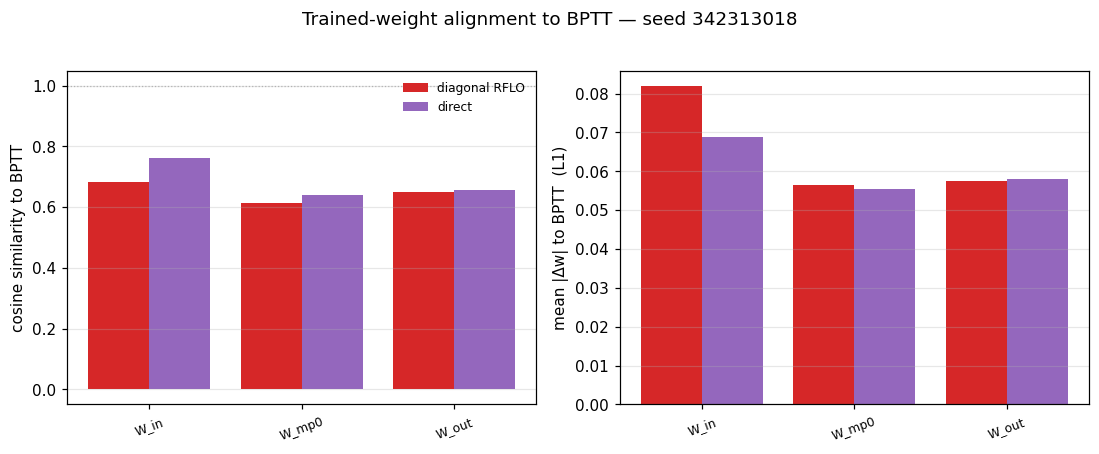

In [5]:
# Compare each rule's TRAINED weights to BPTT's, per component, via cosine + L1.
REF = "bptt"
if REF not in comp:
    print(f"reference '{REF}' not among loaded rules {list(comp)}; skipping alignment.")
else:
    keys = [k for k, _ in cols]                     # W_in, W_mp0, ..., W_out
    others = [r for r in RULES if r != REF]

    def _cos(a, b):
        a = a.ravel().astype(np.float64); b = b.ravel().astype(np.float64)
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        return float(a @ b / (na * nb)) if na > 0 and nb > 0 else float("nan")

    def _l1(a, b):        # mean |Δ| per weight
        return float(np.abs(a.ravel() - b.ravel()).mean())

    def _rel_l1(a, b):    # ‖Δ‖₁ / ‖b‖₁  (scale-free)
        denom = np.abs(b.ravel()).sum()
        return float(np.abs(a.ravel() - b.ravel()).sum() / denom) if denom > 0 else float("nan")

    cos_tab = {r: {} for r in others}   # cos_tab[rule][key]
    l1_tab  = {r: {} for r in others}
    rel_tab = {r: {} for r in others}
    for r in others:
        for k in keys:
            a, b = comp[r][k], comp[REF][k]
            cos_tab[r][k] = _cos(a, b)
            l1_tab[r][k]  = _l1(a, b)
            rel_tab[r][k] = _rel_l1(a, b)

    # Table.
    print(f"Trained-weight alignment to {RULE_LABEL.get(REF, REF)} "
          f"(seed {SEED}, {n_layers} MP layer{'s' if n_layers != 1 else ''}):")
    print(f"  {'rule':16} {'component':10} {'cosine':>9} {'mean L1':>10} {'rel L1':>9}")
    for r in others:
        for k in keys:
            print(f"  {RULE_LABEL.get(r, r):16} {k:10} "
                  f"{cos_tab[r][k]:>9.4f} {l1_tab[r][k]:>10.3e} {rel_tab[r][k]:>9.3f}")

    # Grouped bar charts: cosine (left) and mean-L1 (right), x = component, bars per rule.
    xs = np.arange(len(keys))
    width = 0.8 / max(len(others), 1)
    fig, (axc, axl) = plt.subplots(1, 2, figsize=(6.5 + 1.2 * len(keys), 4.0))
    for i, r in enumerate(others):
        off = (i - (len(others) - 1) / 2) * width
        c = RULE_COLOR.get(r)
        axc.bar(xs + off, [cos_tab[r][k] for k in keys], width, color=c,
                label=RULE_LABEL.get(r, r))
        axl.bar(xs + off, [l1_tab[r][k] for k in keys], width, color=c,
                label=RULE_LABEL.get(r, r))
    axc.axhline(1.0, color="0.7", lw=0.8, ls=":")   # perfect direction match
    axc.set_ylabel(f"cosine similarity to {RULE_LABEL.get(REF, REF)}")
    axc.set_ylim(min(0.0, min(cos_tab[r][k] for r in others for k in keys)) - 0.05, 1.05)
    axl.set_ylabel(f"mean |Δw| to {RULE_LABEL.get(REF, REF)}  (L1)")
    for ax in (axc, axl):
        ax.set_xticks(xs); ax.set_xticklabels(keys, rotation=20, fontsize=8)
        ax.grid(alpha=0.3, axis="y")
    axc.legend(frameon=False, fontsize=8)
    fig.suptitle(f"Trained-weight alignment to {RULE_LABEL.get(REF, REF)} — seed {SEED}",
                 y=1.02, fontsize=12)
    fig.tight_layout()
    save_fig(fig, "weight_alignment_to_bptt")
    plt.show()

## 4. Weight distributions (overlaid histograms)

For each weight matrix, overlay the flattened weight distributions of
the learning rules on shared bins. This shows how the *shape/spread* of
the learned weights differs across rules (e.g. whether a local rule
learns systematically larger / more sparse weights than BPTT), which the
heatmaps above don't make quantitative.

saved figure -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure/notebooks/dmpn_contextdelaydm1_h200_b128_n5000_lr1e-03_direct_fa_fbnorm_in-match_eta1.00_lam0.99_seed342313018_weight_distributions.png


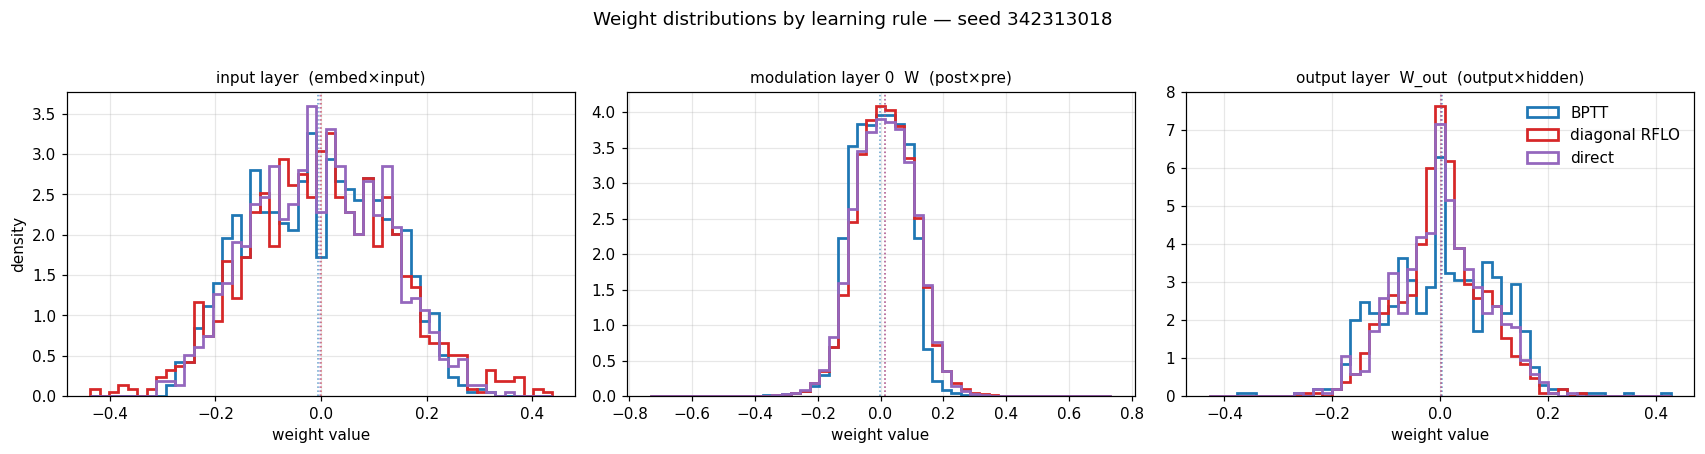

component  rule                  mean       std    max|w|
W_in       BPTT             -6.348e-03 1.254e-01 3.147e-01
W_in       diagonal RFLO    -9.377e-04 1.376e-01 4.374e-01
W_in       direct           -2.404e-03 1.233e-01 3.550e-01
W_mp0      BPTT             -1.973e-03 8.421e-02 7.355e-01
W_mp0      diagonal RFLO    1.583e-02 9.068e-02 5.000e-01
W_mp0      direct           1.317e-02 9.178e-02 4.760e-01
W_out      BPTT             3.683e-03 1.026e-01 4.284e-01
W_out      diagonal RFLO    1.177e-03 7.719e-02 2.560e-01
W_out      direct           1.604e-03 8.292e-02 2.624e-01


In [6]:
fig, axes = plt.subplots(1, len(cols), figsize=(5.2 * len(cols), 4.0),
                         squeeze=False)
for j, (key, title) in enumerate(cols):
    ax = axes[0][j]
    # Shared symmetric bins across rules for a fair overlay.
    vmax = max(np.abs(comp[r][key]).max() for r in RULES)
    bins = np.linspace(-vmax, vmax, 50)
    for rule in RULES:
        w = comp[rule][key].ravel()
        ax.hist(w, bins=bins, density=True, histtype='step', linewidth=1.8,
                color=RULE_COLOR.get(rule), label=RULE_LABEL.get(rule, rule))
        ax.axvline(w.mean(), color=RULE_COLOR.get(rule), ls=':', lw=1, alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('weight value')
    ax.grid(alpha=0.3)
axes[0][0].set_ylabel('density')
axes[0][-1].legend(frameon=False)
fig.suptitle(f'Weight distributions by learning rule — seed {SEED}', y=1.02)
fig.tight_layout()
save_fig(fig, "weight_distributions")
plt.show()

# Per-rule distribution statistics (mean, std, max|w|) for every component.
print(f"{'component':10} {'rule':16} {'mean':>9} {'std':>9} {'max|w|':>9}")
for key, _ in cols:
    for rule in RULES:
        w = comp[rule][key].ravel()
        print(f'{key:10} {RULE_LABEL.get(rule, rule):16} '
              f'{w.mean():>9.3e} {w.std():>9.3e} {np.abs(w).max():>9.3e}')